In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/4_청구입금정보_segment_병합.csv")
df

,Segment,기준년월,ID,대표결제일,대표결제방법코드,대표청구지고객주소구분코드,대표청구서수령지구분코드,청구서수령방법,청구서발송여부_B0,청구서발송여부_R3M,...,할인금액_청구서_B0M,상환개월수_결제일_R6M,상환개월수_결제일_R3M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,혜택수혜금액_R3M,포인트_마일리지_환산_B0M,혜택수혜금액
0,3,201807,0,27,0,0,2,2,1,1,...,0,5,3,0,0,1,0,3,0,0
1,4,201807,1,13,0,1,5,4,1,1,...,163,6,3,0,0,0,0,0,0,0
2,2,201807,2,1,0,0,6,5,1,1,...,0,6,3,0,0,0,0,121,0,50
3,3,201807,3,5,0,1,5,4,1,1,...,0,5,3,2,0,0,0,3,0,2
4,4,201807,4,13,0,1,5,4,0,1,...,0,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,4,201812,399995,25,0,1,5,4,0,0,...,0,0,0,0,0,0,0,0,0,0
2399996,3,201812,399996,20,0,0,6,5,1,1,...,0,6,3,0,0,0,0,164,0,53
2399997,2,201812,399997,20,0,2,5,4,1,1,...,0,6,3,0,0,0,0,0,0,0
2399998,4,201812,399998,20,0,1,5,4,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df['청구서발송여부_all'] = (
    (df['청구서발송여부_B0'] == 1) &
    (df['청구서발송여부_R3M'] == 1) &
    (df['청구서발송여부_R6M'] == 1)
).astype(int)

cols1 = pd.crosstab(df['Segment'],df['청구서발송여부_all'])
cols1

청구서발송여부_all,0,1
Segment,,
0,12,960
1,0,144
2,5948,121642
3,21820,327422
4,565800,1356252


In [4]:
df['청구금액_합'] = df['청구금액_R6M'] + df['청구금액_R3M'] + df['청구금액_B0']

In [5]:
col_summary = df.groupby('Segment').agg(
    total_count=('청구금액_합', 'count'),
    zero_count=('청구금액_합', lambda x: (x == 0).sum())
).reset_index()

col_summary['zero_ratio'] = col_summary['zero_count'] / col_summary['total_count']
col_summary

,Segment,total_count,zero_count,zero_ratio
0,0,972,0,0.000000
1,1,144,0,0.000000
2,2,127590,1763,0.013818
3,3,349242,7151,0.020476
4,4,1922052,344002,0.178976


In [6]:
X = df[['청구금액_R6M', '청구금액_R3M', '청구금액_B0']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

In [7]:
pca_df = pd.DataFrame(X_pca, columns=['청구금액_PCA'])
pca_df.head()

,청구금액_PCA
0,1.942009
1,-0.261380
2,4.519809
3,3.067663
4,-1.145513


In [22]:
df['청구금액_PCA'] = X_pca

In [36]:
df1 = df.copy()
df1 = df1[df1['포인트_마일리지_환산_B0M'] != 0]

df1

,Segment,기준년월,ID,대표결제일,대표결제방법코드,대표청구지고객주소구분코드,대표청구서수령지구분코드,청구서수령방법,청구서발송여부_B0,청구서발송여부_R3M,...,상환개월수_결제일_R3M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,혜택수혜금액_R3M,포인트_마일리지_환산_B0M,혜택수혜금액,청구서발송여부_all,청구금액_PCA
16,4,201807,16,12,0,0,6,5,1,1,...,2,0,0,3,2,129,99,0,1,-0.501926
37,2,201807,37,27,0,0,6,5,1,1,...,3,0,0,0,0,1250,214,279,1,2.925855
50,4,201807,50,23,0,0,6,5,1,1,...,3,0,0,0,0,119,74,2,1,-0.949984
55,2,201807,55,12,0,1,5,4,1,1,...,3,0,0,0,0,1250,262,279,1,6.776537
91,3,201807,91,25,0,1,5,4,1,1,...,3,0,0,0,0,129,77,52,1,0.885272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399875,2,201812,399875,23,0,1,5,4,1,1,...,0,0,0,6,3,167,52,52,1,1.350441
2399877,4,201812,399877,13,0,0,6,5,1,1,...,3,0,0,0,0,59,165,57,1,-0.877251
2399912,4,201812,399912,5,0,0,6,5,1,1,...,3,0,0,0,0,2,163,2,1,-0.263951
2399920,4,201812,399920,25,0,1,5,4,1,1,...,3,0,0,0,0,161,72,53,1,0.003940


In [40]:
col1 = df1.groupby('Segment')['포인트_마일리지_환산_B0M'].describe()
col1

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,676.0,238.800296,97.006056,71.0,162.00,204.0,318.00,517.0
1,72.0,288.638889,108.404993,62.0,205.75,303.5,367.25,469.0
2,30350.0,199.204745,91.221427,42.0,123.00,180.0,267.00,607.0
3,40009.0,160.774751,72.153936,40.0,97.00,152.0,208.00,574.0
4,47886.0,133.140855,61.666481,41.0,82.00,123.0,164.00,519.0


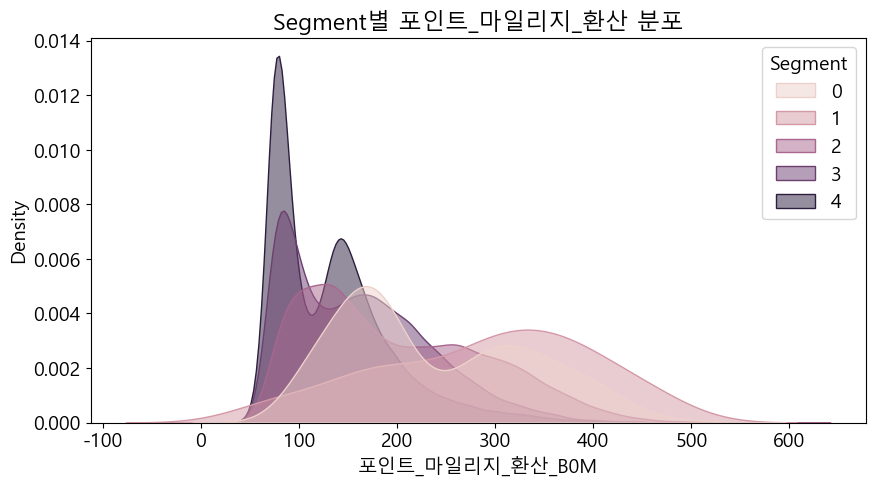

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.kdeplot(data=df1, x='포인트_마일리지_환산_B0M', hue='Segment', fill=True, common_norm=False, alpha=0.5)
plt.title('Segment별 포인트_마일리지_환산 분포')
plt.show()

In [ ]:
a3 = a3['']